STEP 1 : IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

STEP 2 : LOAD DATASET

In [ ]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


STEP 3 : BASIC INFO

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


STEP 4 : DATA CLEANING

In [ ]:
# Remove customer ID
df.drop('customerID', axis=1, inplace=True)

#Convert TotalCharges
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [ ]:
#Fill missing values
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

/tmp/ipykernel_1156/1386750037.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


STEP 5 : EDA

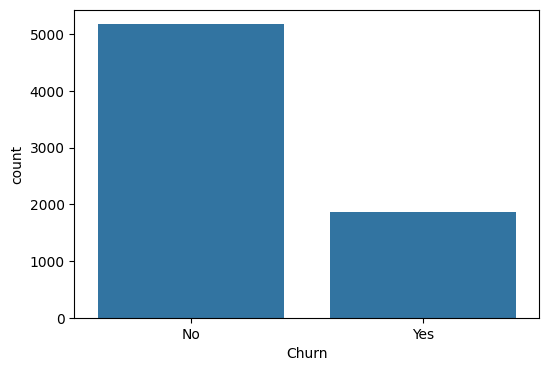

In [ ]:
#Churn Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.show()

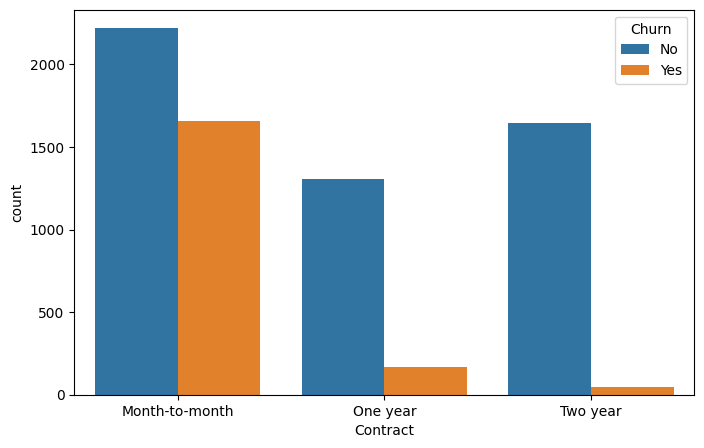

In [ ]:
#Contract vs Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.show()

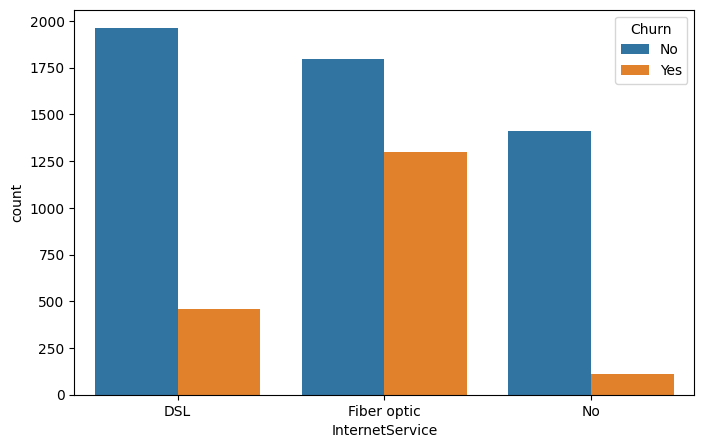

In [ ]:
#Internet Service vs Churn
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.show()

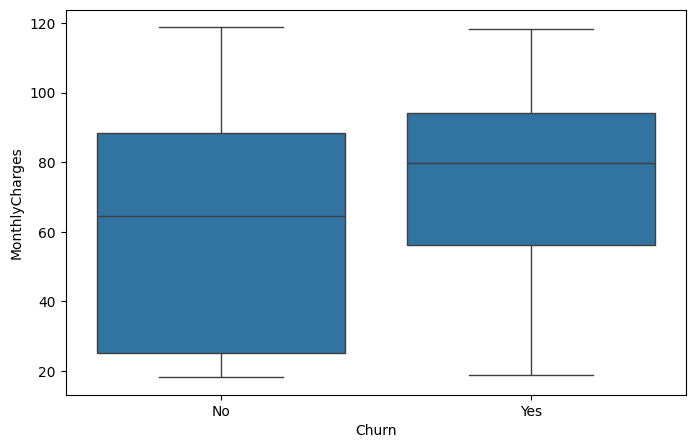

In [ ]:
#Monthly Charges
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.show()

STEP 6 : FEATURE ENGINEERING

In [ ]:
#Create Customer Lifetime Value
df['CLV'] = (
    df['MonthlyCharges']
    * df['tenure']
)

In [ ]:
#Create Customer Type
df['CustomerType'] = np.where(
    df['tenure'] > 24,
    'Loyal',
    'New'
)

STEP 7 : ENCODING

In [ ]:
dashboard_df = df.copy()

dashboard_df.to_csv(
    'dashboard_dataset.csv',
    index=False
)

from google.colab import files
files.download('dashboard_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col])

STEP 8 : SPLIT FEATURES AND TARGET

In [ ]:
X = df.drop('Churn', axis=1)

y = df['Churn']

STEP 9 : TRAIN-TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

STEP 10 :SCALING

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

STEP 11 : LOGISTIC REGRESSION

In [ ]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

y_pred = lr.predict(X_test)

STEP 12 : EVALUATION

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1:",
    f1_score(y_test, y_pred)
)

Accuracy: 0.8161816891412349
Precision: 0.6826923076923077
Recall: 0.5710455764075067
F1: 0.621897810218978


STEP 13: ROC AUC

In [ ]:
y_prob = lr.predict_proba(X_test)[:,1]

auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC:", auc)

ROC AUC: 0.8611371329199746


STEP 14: CONFUSION MATRIX

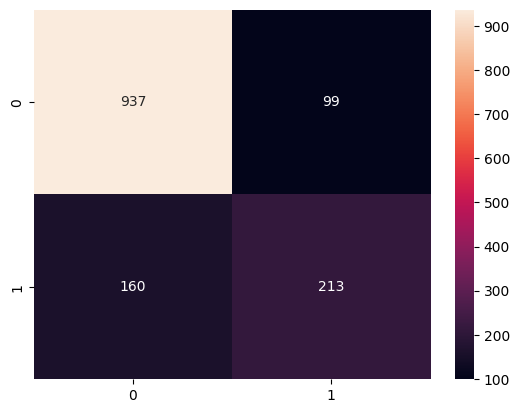

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

STEP 15: RANDOM FOREST

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

STEP 16: COMPARE MODELS

In [ ]:
print(
    "Logistic Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    "RF Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

Logistic Accuracy: 0.8161816891412349
RF Accuracy: 0.7927608232789212


STEP 17: FEATURE IMPORTANCE

In [ ]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    importance.head(10)
)

            Feature  Importance
17   MonthlyCharges    0.149480
18     TotalCharges    0.142045
19              CLV    0.138786
4            tenure    0.120879
14         Contract    0.074607
8    OnlineSecurity    0.047362
16    PaymentMethod    0.045741
11      TechSupport    0.032933
7   InternetService    0.025634
0            gender    0.024463


STEP 18: PLOT FEATURE IMPORTANCE

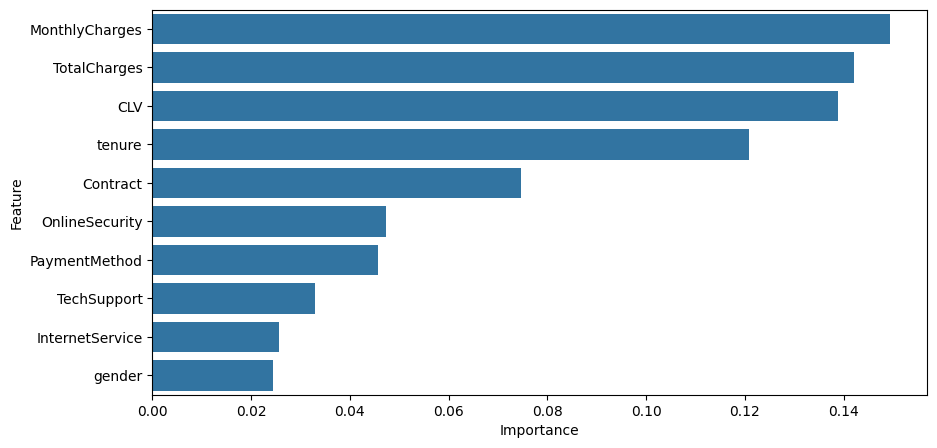

In [ ]:
plt.figure(
    figsize=(10,5)
)

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.show()

STEP 19: SAVE MODEL

In [ ]:
import joblib

joblib.dump(
    rf,
    'churn_model.pkl'
)

['churn_model.pkl']

In [ ]:
results = pd.DataFrame(X_test, columns=X.columns)

results['Actual_Churn'] = y_test.values
results['Predicted_Churn'] = rf_pred

results['Risk_Score'] = rf.predict_proba(X_test)[:,1]

results.to_csv(
    'churn_dashboard_data.csv',
    index=False
)

In [ ]:
df.to_csv('cleaned_churn_data.csv', index=False)
from google.colab import files

files.download('cleaned_churn_data.csv')

# Scale the entire feature set X before making predictions
X_scaled_for_full_df = scaler.transform(X)

df['Predicted_Churn'] = rf.predict(X_scaled_for_full_df)

df.to_csv(
    'churn_dashboard_data.csv',
    index=False
)

from google.colab import files

files.download(
    'churn_dashboard_data.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>